# FittedHet

Train two fixed-heterogeneity SHD RSNN variants matched to the 32-neuron Local-Het architecture.

- Variant A: Gamma tau_syn and Log-Normal tau_mem
- Variant B: Gamma tau_syn and Log-Uniform tau_mem
- Both variants freeze the sampled per-neuron time constants and train only the weights.

In [2]:
from __future__ import annotations

import sys
import json
import time
import random
from contextlib import contextmanager
from pathlib import Path

import importlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma as scipy_gamma, lognorm

import torch

PROJECT_ROOT = Path(r"C:\Users\Priya\Desktop\research project (SNN Info Theory)")
WIMFO_ROOT = PROJECT_ROOT / "wimfo"
PAPER_ROOT = PROJECT_ROOT / "neural_heterogeneity" / "SuGD_code"
CHECKPOINT_DIR = PROJECT_ROOT / "Project Files"
FITTED_CHECKPOINT_DIR = CHECKPOINT_DIR / "Checkpoints"
CHECKPOINT_PATH = FITTED_CHECKPOINT_DIR / "network_A_checkpoint.pt"
TAU_ARTIFACT_PATH = PROJECT_ROOT / "Tau from 15 epoch run.json"
SHD_TRAIN = PROJECT_ROOT / "data" / "shd" / "shd_train.h5"
SHD_TEST = PROJECT_ROOT / "data" / "shd" / "shd_test.h5"

for extra_path in [WIMFO_ROOT, PAPER_ROOT]:
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

from clipper import ZeroOneClipper
from data_gen import open_file, sparse_data_generator
from reg_loss import loss as repo_loss
from SuSpike import SuSpike

RSNN = importlib.import_module("model").RSNN
clipper = ZeroOneClipper()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
spike_fn = SuSpike.apply

print(f"Device: {DEVICE}")
print(f"Local-Het checkpoint exists: {CHECKPOINT_PATH.exists()}")
print(f"Tau artifact exists: {TAU_ARTIFACT_PATH.exists()}")
print(f"Train file exists: {SHD_TRAIN.exists()}")
print(f"Test file exists: {SHD_TEST.exists()}")

Device: cuda
Local-Het checkpoint exists: True
Tau artifact exists: True
Train file exists: True
Test file exists: True


In [4]:
SHD_DEFAULTS = {
    "seed": 1000,
    "dtype": torch.float,
    "device": DEVICE,
    "cuda": DEVICE.type == "cuda",
    "nb_inputs": 700,
    "nb_hidden": [],
    "nb_recurrent": 32,
    "nb_outputs": 20,
    "batch_size": 256,
    "time_step": 1.0e-3,
    "nb_steps": 1000,
    "tau_syn": 10e-3,
    "tau_mem": 20e-3,
    "threshold": 1.0,
    "tref": 0.0,
    "dist": "gamma",
    "dist_prms": 3.0,
    "lr": 4e-3,
    "lr_ab": 4e-3,
    "betas": [0.9, 0.999],
    "weight_decay": 0.0,
    "nb_epochs": 25,
    "drop_last": True,
    "sl": 0.0,
    "thetal": 0.0,
    "su": 0.0,
    "thetau": 0.0,
    "rate": 0.0,
    "p_del": 0.0,
    "train_th": 0,
    "het_th": 0,
    "train_reset": 0,
    "het_reset": 0,
    "train_rest": 0,
    "het_rest": 0,
    "sparse_data_generator": "sparse_data_generator",
    "time_scale": [0.5, 1.0],
    "model": "RSNN",
    "savestep": 10,
    "clip": 1,
    "plot_step": 50,
    "class_list": list(range(20)),
    "het_ab": 1,
    "train_ab": 0,
    "train_hom_ab": 0,
}

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def tau_ms_to_decay(tau_ms, time_step):
    tau_s = np.asarray(tau_ms, dtype=np.float64) * 1e-3
    tau_s = np.clip(tau_s, time_step * 1.001, None)
    return np.exp(-time_step / tau_s)


def decay_to_tau(decay, time_step):
    decay = np.clip(np.asarray(decay, dtype=np.float64), 1e-9, 1 - 1e-9)
    return -time_step / np.log(decay)


def summarize_hidden_taus(model, time_step: float):
    hidden_layer = model.network[0]
    alpha = hidden_layer.alpha.detach().cpu().numpy().ravel()
    beta = hidden_layer.beta.detach().cpu().numpy().ravel()
    return {
        "alpha_unique": int(np.unique(np.round(alpha, 8)).size),
        "beta_unique": int(np.unique(np.round(beta, 8)).size),
        "tau_syn_ms_min": float(decay_to_tau(alpha, time_step).min() * 1e3),
        "tau_syn_ms_max": float(decay_to_tau(alpha, time_step).max() * 1e3),
        "tau_mem_ms_min": float(decay_to_tau(beta, time_step).min() * 1e3),
        "tau_mem_ms_max": float(decay_to_tau(beta, time_step).max() * 1e3),
    }


def save_model_checkpoint(path, model, history, elapsed_s, prms, extra=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "model_state_dict": model.state_dict(),
        "history": history,
        "elapsed_s": float(elapsed_s),
        "prms": {k: v for k, v in prms.items() if not isinstance(v, (torch.dtype, torch.device))},
    }
    if extra:
        payload.update(extra)
    torch.save(payload, path)
    return path


@contextmanager
def shd_open(path):
    units, times, labels = open_file(str(path))
    try:
        yield units, times, labels
    finally:
        units._v_file.close()


class SHDCache:
    def __init__(self, path):
        raw_u, raw_t, raw_l = open_file(str(path))
        self.units = list(raw_u[:])
        self.times = list(raw_t[:])
        self.labels = np.array(raw_l[:])
        raw_u._v_file.close()
        print(f"  SHDCache: {len(self.labels)} samples loaded from {Path(str(path)).name}")


def _is_cache(obj):
    return hasattr(obj, "units") and hasattr(obj, "times") and hasattr(obj, "labels")


@contextmanager
def shd_open_cached(cache):
    yield cache.units, cache.times, cache.labels


def fast_sparse_data_generator(units, times, labels, prms, shuffle=True, epoch=0, drop_last=True):
    rate = prms.get("rate", 0.0)
    p_del = prms.get("p_del", 0.0)
    if rate != 0.0 or p_del != 0.0:
        yield from sparse_data_generator(units, times, labels, prms, shuffle=shuffle, epoch=epoch, drop_last=drop_last)
        return

    seed = prms["seed"] + epoch
    batch_size = prms["batch_size"]
    nb_steps = prms["nb_steps"]
    nb_units = prms["nb_inputs"]
    inv_dt = 1.0 / prms["time_step"]
    class_list = prms["class_list"]

    label_arr = labels if isinstance(labels, np.ndarray) else np.array(labels[:])
    sample_index = np.where(np.isin(label_arr, class_list))[0]
    num_samples = len(sample_index)
    n_batches = (num_samples // batch_size) if drop_last else -(-num_samples // batch_size)

    np.random.seed(seed)
    if shuffle:
        np.random.shuffle(sample_index)

    for counter in range(n_batches):
        batch_index = sample_index[batch_size * counter:min(num_samples, batch_size * (counter + 1))]
        actual_bs = len(batch_index)
        t_arrays = [np.round(times[idx] * inv_dt).astype(np.int64) for idx in batch_index]
        u_arrays = [units[idx] for idx in batch_index]
        lengths = np.array([len(a) for a in t_arrays], dtype=np.int64)

        if lengths.sum():
            all_ts = np.concatenate(t_arrays)
            all_us = np.concatenate(u_arrays)
            all_bc = np.repeat(np.arange(actual_bs, dtype=np.int64), lengths)
            valid = all_ts < nb_steps
            all_ts, all_us, all_bc = all_ts[valid], all_us[valid], all_bc[valid]
            i = torch.from_numpy(np.stack([all_bc, all_ts, all_us]))
            v = torch.ones(all_ts.size, dtype=torch.float32)
            X_batch = torch.sparse_coo_tensor(i, v, torch.Size([actual_bs, nb_steps, nb_units])).to_dense()
        else:
            X_batch = torch.zeros(actual_bs, nb_steps, nb_units)

        X_batch.clamp_(max=1.0)
        y_batch = torch.tensor([class_list.index(int(a)) for a in label_arr[batch_index]], dtype=torch.long)
        yield X_batch, y_batch


def shd_generator(units, times, labels, prms, shuffle, epoch, drop_last):
    yield from fast_sparse_data_generator(units, times, labels, prms, shuffle=shuffle, epoch=epoch, drop_last=drop_last)


def count_epoch_samples(sample_count, batch_size, drop_last):
    if drop_last:
        return (sample_count // batch_size) * batch_size
    return sample_count


def forward_logits(model, x):
    layer_recs = model(0, 0, x)
    output_layer = layer_recs[-1]
    logits, _ = torch.max(output_layer[1], dim=1)
    return logits, layer_recs


def make_optimizer(model, prms):
    trainable = [param for param in model.parameters() if param.requires_grad]
    return torch.optim.Adam(trainable, lr=prms["lr"], betas=tuple(prms["betas"]), weight_decay=prms["weight_decay"])


@torch.no_grad()
def evaluate_batches(model, prms, units, times, labels, num_samples=None, use_amp=True):
    if num_samples is None:
        total = int(np.isin(labels[:], prms["class_list"]).sum())
        num_samples = count_epoch_samples(total, prms["batch_size"], drop_last=False)
    use_amp = use_amp and DEVICE.type == "cuda"
    model.eval()
    loss_acc, correct = 0.0, 0
    for x, y in shd_generator(units, times, labels, prms, shuffle=False, epoch=0, drop_last=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=use_amp):
            logits, layer_recs = forward_logits(model, x)
            loss_acc += repo_loss(logits, layer_recs, y, num_samples, prms).item()
        correct += (logits.argmax(1) == y).sum().item()
    return {"loss": loss_acc, "acc": correct / max(num_samples, 1), "n": num_samples}


def train_experiment(model, prms, train_data, test_data, use_amp=True):
    use_amp = use_amp and DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    optimizer = make_optimizer(model, prms)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    tr_ctx = shd_open_cached if _is_cache(train_data) else shd_open
    te_ctx = shd_open_cached if _is_cache(test_data) else shd_open
    with tr_ctx(train_data) as (u_tr, t_tr, l_tr), te_ctx(test_data) as (u_te, t_te, l_te):
        if not prms["class_list"]:
            prms["class_list"] = np.unique(l_tr[:]).tolist()
        total_tr = int(np.isin(l_tr[:], prms["class_list"]).sum())
        total_te = int(np.isin(l_te[:], prms["class_list"]).sum())
        eff_tr = count_epoch_samples(total_tr, prms["batch_size"], drop_last=bool(prms["drop_last"]))
        eff_te = count_epoch_samples(total_te, prms["batch_size"], drop_last=False)

        if prms["clip"]:
            model.apply(clipper)

        for epoch in range(1, prms["nb_epochs"] + 1):
            ep_t0 = time.perf_counter()
            model.train()
            ep_loss, ep_correct = 0.0, 0
            for x, y in shd_generator(u_tr, t_tr, l_tr, prms, shuffle=True, epoch=epoch, drop_last=prms["drop_last"]):
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=use_amp):
                    logits, layer_recs = forward_logits(model, x)
                    loss_val = repo_loss(logits, layer_recs, y, eff_tr, prms)
                scaler.scale(loss_val).backward()
                scaler.step(optimizer)
                scaler.update()
                if prms["clip"]:
                    model.apply(clipper)
                ep_loss += loss_val.item()
                ep_correct += (logits.argmax(1) == y).sum().item()

            test_m = evaluate_batches(model, prms, u_te, t_te, l_te, num_samples=eff_te, use_amp=use_amp)
            history["train_loss"].append(ep_loss)
            history["train_acc"].append(ep_correct / max(eff_tr, 1))
            history["test_loss"].append(test_m["loss"])
            history["test_acc"].append(test_m["acc"])
            ep_elapsed = time.perf_counter() - ep_t0
            print(f"epoch={epoch:03d} train_acc={ep_correct/max(eff_tr,1):.3f} test_acc={test_m['acc']:.3f} ({ep_elapsed/60:.1f} min)")

    return history


print("Training helpers loaded.")

Training helpers loaded.


In [5]:
print("Pre-loading SHD training data into RAM...")
SHD_TRAIN_CACHE = SHDCache(SHD_TRAIN)
print("Pre-loading SHD test data into RAM...")
SHD_TEST_CACHE = SHDCache(SHD_TEST)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
saved_prms = dict(checkpoint["prms"])
local_het_reference_acc = float(checkpoint["history"]["test_acc"][-1])

with open(TAU_ARTIFACT_PATH, "r", encoding="utf-8") as handle:
    tau_artifact = json.load(handle)

artifact_syn_ms = np.asarray(tau_artifact["heterogeneous"]["tau_syn_ms"], dtype=np.float64)
artifact_mem_ms = np.asarray(tau_artifact["heterogeneous"]["tau_mem_ms"], dtype=np.float64)
syn_shape, _, syn_scale = scipy_gamma.fit(artifact_syn_ms, floc=0.0)
mem_lognorm_shape, _, mem_lognorm_scale = lognorm.fit(artifact_mem_ms, floc=0.0)
artifact_syn_bounds = (float(artifact_syn_ms.min()), float(artifact_syn_ms.max()))
artifact_mem_bounds = (float(artifact_mem_ms.min()), float(artifact_mem_ms.max()))

def sample_gamma_syn_ms(size, rng):
    values = scipy_gamma.rvs(syn_shape, loc=0.0, scale=syn_scale, size=size, random_state=rng)
    return np.clip(values, artifact_syn_bounds[0], artifact_syn_bounds[1])


def sample_lognormal_mem_ms(size, rng):
    values = lognorm.rvs(mem_lognorm_shape, loc=0.0, scale=mem_lognorm_scale, size=size, random_state=rng)
    return np.clip(values, artifact_mem_bounds[0], artifact_mem_bounds[1])


def sample_loguniform_mem_ms(size, rng):
    low, high = artifact_mem_bounds
    return np.exp(rng.uniform(np.log(low), np.log(high), size=size))


def build_variant_prms(saved_prms):
    prms = dict(SHD_DEFAULTS)
    prms.update(saved_prms)
    prms.update({
        "dtype": torch.float,
        "device": DEVICE,
        "cuda": DEVICE.type == "cuda",
        "het_ab": 1,
        "train_ab": 0,
        "train_hom_ab": 0,
    })
    prms["alpha"] = float(np.exp(-prms["time_step"] / prms["tau_syn"]))
    prms["beta"] = float(np.exp(-prms["time_step"] / prms["tau_mem"]))
    return prms


def configure_fixed_tau_variant(label, syn_sampler, mem_sampler, seed_offset):
    prms = build_variant_prms(saved_prms)
    model_seed = int(prms["seed"]) + int(seed_offset)
    set_seed(model_seed)
    model = RSNN(prms, rec=True).to(DEVICE)

    hidden_size = int(model.network[0].output_size)
    rng = np.random.default_rng(model_seed)
    tau_syn_ms = np.asarray(syn_sampler(hidden_size, rng), dtype=np.float64)
    tau_mem_ms = np.asarray(mem_sampler(hidden_size, rng), dtype=np.float64)

    alpha = tau_ms_to_decay(tau_syn_ms, prms["time_step"]).reshape(1, -1)
    beta = tau_ms_to_decay(tau_mem_ms, prms["time_step"]).reshape(1, -1)
    with torch.no_grad():
        hidden_layer = model.network[0]
        hidden_layer.alpha.copy_(torch.tensor(alpha, device=DEVICE, dtype=prms["dtype"]))
        hidden_layer.beta.copy_(torch.tensor(beta, device=DEVICE, dtype=prms["dtype"]))
        hidden_layer.alpha.requires_grad_(False)
        hidden_layer.beta.requires_grad_(False)

    return {
        "label": label,
        "seed": model_seed,
        "model": model,
        "prms": prms,
        "tau_syn_ms": tau_syn_ms,
        "tau_mem_ms": tau_mem_ms,
        "initial_summary": summarize_hidden_taus(model, prms["time_step"]),
    }


variant_a = configure_fixed_tau_variant(
    "FittedHet-LogNormMem-GammaSyn",
    syn_sampler=sample_gamma_syn_ms,
    mem_sampler=sample_lognormal_mem_ms,
    seed_offset=101,
)
variant_b = configure_fixed_tau_variant(
    "FittedHet-LogUniformMem-GammaSyn",
    syn_sampler=sample_gamma_syn_ms,
    mem_sampler=sample_loguniform_mem_ms,
    seed_offset=202,
)

variant_results = {
    variant_a["label"]: variant_a,
    variant_b["label"]: variant_b,
}

print("Fitted synaptic Gamma parameters")
print(f"shape={syn_shape:.4f} scale={syn_scale:.4f} bounds_ms={artifact_syn_bounds}")
print("Fitted membrane Log-Normal parameters")
print(f"shape={mem_lognorm_shape:.4f} scale={mem_lognorm_scale:.4f} bounds_ms={artifact_mem_bounds}")
print(f"Local-Het checkpoint reference acc: {local_het_reference_acc:.3f}")
for variant in [variant_a, variant_b]:
    print(f"\n{variant['label']}")
    print(variant["initial_summary"])

Pre-loading SHD training data into RAM...
  SHDCache: 8156 samples loaded from shd_train.h5
Pre-loading SHD test data into RAM...
  SHDCache: 2264 samples loaded from shd_test.h5
Fitted synaptic Gamma parameters
shape=1.0304 scale=22.7390 bounds_ms=(1.9844942396285434, 99.74988651190043)
Fitted membrane Log-Normal parameters
shape=0.9888 scale=25.4979 bounds_ms=(2.0721413126176835, 99.74988651190043)
Local-Het checkpoint reference acc: 0.649

FittedHet-LogNormMem-GammaSyn
{'alpha_unique': 32, 'beta_unique': 31, 'tau_syn_ms_min': 1.984494247339813, 'tau_syn_ms_max': 97.37569894323957, 'tau_mem_ms_min': 5.755225483265454, 'tau_mem_ms_max': 99.74962916323692}

FittedHet-LogUniformMem-GammaSyn
{'alpha_unique': 28, 'beta_unique': 32, 'tau_syn_ms_min': 1.984494247339813, 'tau_syn_ms_max': 68.69545272112714, 'tau_mem_ms_min': 2.8859507556782606, 'tau_mem_ms_max': 93.51755706141412}


## Train Variant A

Gamma tau_syn and Log-Normal tau_mem.

In [6]:
variant = variant_results["FittedHet-LogNormMem-GammaSyn"]
train_t0 = time.perf_counter()
variant["history"] = train_experiment(variant["model"], variant["prms"], SHD_TRAIN_CACHE, SHD_TEST_CACHE, use_amp=True)
variant["elapsed_s"] = time.perf_counter() - train_t0
variant["final_summary"] = summarize_hidden_taus(variant["model"], variant["prms"]["time_step"])
variant["checkpoint_path"] = save_model_checkpoint(
    FITTED_CHECKPOINT_DIR / "fittedhet_lognorm_mem_gamma_syn_checkpoint.pt",
    variant["model"],
    variant["history"],
    variant["elapsed_s"],
    variant["prms"],
    extra={
        "label": variant["label"],
        "tau_syn_ms": variant["tau_syn_ms"].tolist(),
        "tau_mem_ms": variant["tau_mem_ms"].tolist(),
        "distribution_family": {"tau_syn": "gamma", "tau_mem": "lognormal"}
    }
)
print(f"{variant['label']} final test acc: {variant['history']['test_acc'][-1]:.3f}")
print(f"Saved checkpoint to: {variant['checkpoint_path']}")
print(f"Elapsed time: {variant['elapsed_s']/60:.1f} min")

epoch=001 train_acc=0.102 test_acc=0.152 (2.1 min)
epoch=002 train_acc=0.204 test_acc=0.281 (2.1 min)
epoch=003 train_acc=0.295 test_acc=0.336 (2.1 min)
epoch=004 train_acc=0.391 test_acc=0.372 (2.1 min)
epoch=005 train_acc=0.454 test_acc=0.443 (2.6 min)
epoch=006 train_acc=0.502 test_acc=0.472 (3.0 min)
epoch=007 train_acc=0.548 test_acc=0.494 (3.0 min)
epoch=008 train_acc=0.600 test_acc=0.561 (3.1 min)
epoch=009 train_acc=0.626 test_acc=0.585 (3.4 min)
epoch=010 train_acc=0.667 test_acc=0.585 (3.5 min)
epoch=011 train_acc=0.675 test_acc=0.597 (3.6 min)
epoch=012 train_acc=0.697 test_acc=0.626 (3.8 min)
epoch=013 train_acc=0.692 test_acc=0.651 (3.2 min)
epoch=014 train_acc=0.744 test_acc=0.673 (2.8 min)
epoch=015 train_acc=0.774 test_acc=0.667 (3.0 min)
epoch=016 train_acc=0.785 test_acc=0.660 (2.8 min)
epoch=017 train_acc=0.800 test_acc=0.680 (2.8 min)
epoch=018 train_acc=0.816 test_acc=0.690 (3.1 min)
epoch=019 train_acc=0.818 test_acc=0.695 (3.3 min)
epoch=020 train_acc=0.818 test_

## Train Variant B

Gamma tau_syn and Log-Uniform tau_mem.

In [7]:
variant = variant_results["FittedHet-LogUniformMem-GammaSyn"]
train_t0 = time.perf_counter()
variant["history"] = train_experiment(variant["model"], variant["prms"], SHD_TRAIN_CACHE, SHD_TEST_CACHE, use_amp=True)
variant["elapsed_s"] = time.perf_counter() - train_t0
variant["final_summary"] = summarize_hidden_taus(variant["model"], variant["prms"]["time_step"])
variant["checkpoint_path"] = save_model_checkpoint(
    FITTED_CHECKPOINT_DIR / "fittedhet_loguniform_mem_gamma_syn_checkpoint.pt",
    variant["model"],
    variant["history"],
    variant["elapsed_s"],
    variant["prms"],
    extra={
        "label": variant["label"],
        "tau_syn_ms": variant["tau_syn_ms"].tolist(),
        "tau_mem_ms": variant["tau_mem_ms"].tolist(),
        "distribution_family": {"tau_syn": "gamma", "tau_mem": "loguniform"}
    }
)
print(f"{variant['label']} final test acc: {variant['history']['test_acc'][-1]:.3f}")
print(f"Saved checkpoint to: {variant['checkpoint_path']}")
print(f"Elapsed time: {variant['elapsed_s']/60:.1f} min")

epoch=001 train_acc=0.074 test_acc=0.112 (3.8 min)
epoch=002 train_acc=0.148 test_acc=0.187 (2.7 min)
epoch=003 train_acc=0.231 test_acc=0.307 (2.7 min)
epoch=004 train_acc=0.284 test_acc=0.305 (2.7 min)
epoch=005 train_acc=0.319 test_acc=0.295 (2.8 min)
epoch=006 train_acc=0.342 test_acc=0.378 (2.7 min)
epoch=007 train_acc=0.397 test_acc=0.413 (2.9 min)
epoch=008 train_acc=0.447 test_acc=0.409 (3.2 min)
epoch=009 train_acc=0.481 test_acc=0.464 (3.2 min)
epoch=010 train_acc=0.521 test_acc=0.501 (2.9 min)
epoch=011 train_acc=0.547 test_acc=0.477 (3.2 min)
epoch=012 train_acc=0.579 test_acc=0.449 (3.1 min)
epoch=013 train_acc=0.590 test_acc=0.521 (2.8 min)
epoch=014 train_acc=0.606 test_acc=0.505 (2.9 min)
epoch=015 train_acc=0.624 test_acc=0.522 (2.8 min)
epoch=016 train_acc=0.631 test_acc=0.514 (2.8 min)
epoch=017 train_acc=0.645 test_acc=0.556 (2.8 min)
epoch=018 train_acc=0.663 test_acc=0.561 (2.8 min)
epoch=019 train_acc=0.664 test_acc=0.572 (2.8 min)
epoch=020 train_acc=0.689 test_

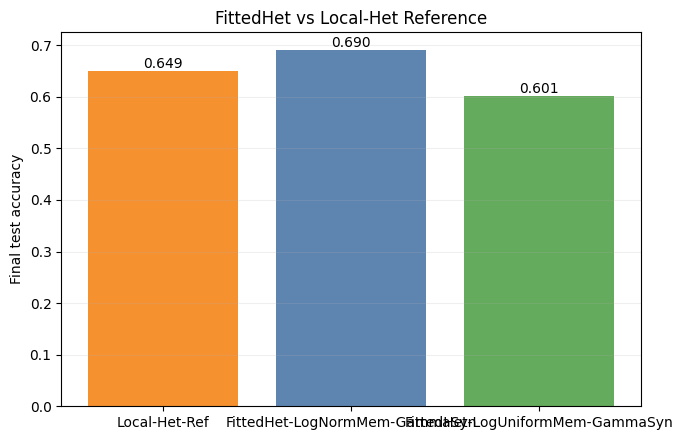

In [8]:
required_labels = ["FittedHet-LogNormMem-GammaSyn", "FittedHet-LogUniformMem-GammaSyn"]
missing = [label for label in required_labels if "history" not in variant_results[label]]
if missing:
    raise RuntimeError(f"Run both training cells first. Missing results for: {missing}")

fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["Local-Het-Ref"] + required_labels
final_accs = [
    local_het_reference_acc,
    variant_results[required_labels[0]]["history"]["test_acc"][-1],
    variant_results[required_labels[1]]["history"]["test_acc"][-1]
]
bars = ax.bar(labels, final_accs, color=["#f58518", "#4c78a8", "#54a24b"], alpha=0.9)
ax.set_ylabel("Final test accuracy")
ax.set_title("FittedHet vs Local-Het Reference")
ax.grid(axis="y", alpha=0.2)
for bar, value in zip(bars, final_accs):
    ax.text(bar.get_x() + bar.get_width()/2, value, f"{value:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()